# 05 — Simulated Annealing aplicado al ATSP

**Variante del TSP — Notebook 5 de 5**

Simulated Annealing acepta ocasionalmente movimientos que empeoran la solución.
En este ATSP se combinan tres propuestas: intercambio, inserción y reversión de
segmento. Como los costos son dirigidos, una reversión puede cambiar tanto los
arcos de borde como la dirección de todos los arcos internos.

## Qué se aprenderá
1. Regla de aceptación de Metropolis.
2. Temperatura inicial estimada desde movimientos reales.
3. Enfriamiento geométrico y tasa de aceptación.
4. Comportamiento con 10, 20, 50 y 100 ciudades.

## Semillas dinámicas de esta versión
- `MASTER_SEED = None` genera una variante nueva cada vez que se ejecuta todo.
- Cada tamaño utiliza semillas independientes y estas se imprimen antes de resolverlo.
- Para repetir una ejecución, copia la semilla maestra impresa y colócala en `MASTER_SEED`.


## 1. Variante estudiada: TSP asimétrico (ATSP)

En el TSP tradicional suele suponerse que la distancia es simétrica:

$$c_{ij}=c_{ji}.$$

En el **Asymmetric Traveling Salesman Problem (ATSP)** esta igualdad no se exige:

$$c_{ij}\neq c_{ji}.$$

Esto representa situaciones reales como calles de un solo sentido, pendientes,
peajes diferentes, viento, congestión o tiempos de viaje dependientes de la
dirección. Se busca una permutación de todas las ciudades que minimice

$$f(\pi)=\sum_{k=0}^{n-1}c_{\pi_k,\pi_{(k+1)\bmod n}}.$$

Los tres tamaños usados son **10, 20, 50 y 100 ciudades**. En cada ejecución se crea una **semilla maestra nueva** y, a partir de ella,
semillas independientes para las instancias y los componentes aleatorios. Todas
se imprimen y se guardan en las tablas. Para repetir un resultado basta con copiar
la semilla maestra mostrada y asignarla a `MASTER_SEED`.


In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_atsp_instance(n, seed=42, asymmetry=0.40):
    """Crea coordenadas y una matriz de costos dirigida para un ATSP."""
    rng = np.random.default_rng(seed)
    coords = rng.uniform(0, 100, size=(n, 2))
    delta = coords[:, None, :] - coords[None, :, :]
    euclidean = np.sqrt((delta ** 2).sum(axis=2))

    directional_factor = 1.0 + asymmetry * rng.uniform(-1.0, 1.0, size=(n, n))
    D = euclidean * directional_factor
    np.fill_diagonal(D, np.inf)
    return coords, D


def tour_cost(tour, D):
    tour = np.asarray(tour, dtype=int)
    return float(D[tour, np.roll(tour, -1)].sum())


def validate_tour(tour, n):
    tour = np.asarray(tour, dtype=int)
    return len(tour) == n and np.array_equal(np.sort(tour), np.arange(n))


def nearest_neighbor(D, start=0):
    """Solución inicial rápida respetando los costos dirigidos."""
    n = len(D)
    unvisited = set(range(n))
    unvisited.remove(start)
    tour = [start]
    while unvisited:
        last = tour[-1]
        nxt = min(unvisited, key=lambda j: D[last, j])
        tour.append(nxt)
        unvisited.remove(nxt)
    return np.asarray(tour, dtype=int)


def random_tour(n, rng):
    """Fija la ciudad 0 al comienzo para eliminar rotaciones equivalentes."""
    return np.r_[0, rng.permutation(np.arange(1, n))]


def asymmetry_index(D):
    """Promedio relativo de |c_ij-c_ji| sobre los arcos fuera de la diagonal."""
    n = len(D)
    mask = ~np.eye(n, dtype=bool)
    forward = D[mask]
    reverse = D.T[mask]
    denom = np.maximum((forward + reverse) / 2.0, 1e-12)
    return float(np.mean(np.abs(forward - reverse) / denom))


def plot_directed_tour(coords, tour, title='', ax=None):
    """Dibuja el ciclo e indica su orientación con flechas."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    tour = np.asarray(tour, dtype=int)
    closed = np.r_[tour, tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], '-o', linewidth=1.3, markersize=4)
    dx = xy[1:, 0] - xy[:-1, 0]
    dy = xy[1:, 1] - xy[:-1, 1]
    ax.quiver(xy[:-1, 0], xy[:-1, 1], dx, dy,
              angles='xy', scale_units='xy', scale=1,
              width=0.003, alpha=0.65)
    if len(coords) <= 20:
        for i, (x, y) in enumerate(coords):
            ax.annotate(str(i), (x, y), xytext=(4, 4),
                        textcoords='offset points', fontsize=8)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    return ax

#Semillas

MASTER_SEED = None

if MASTER_SEED is None:
    RUN_SEED = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
else:
    RUN_SEED = int(MASTER_SEED)

seed_rng = np.random.default_rng(RUN_SEED)
SIZES = [10, 20, 50, 100]


def next_seed():
    """Entrega una semilla uint32 independiente y compatible con NumPy."""
    return int(seed_rng.integers(0, 2**32, dtype=np.uint32))


INSTANCE_SEEDS = {n: next_seed() for n in SIZES}
START_SEEDS = {n: next_seed() for n in SIZES}
TEMPERATURE_SEEDS = {n: next_seed() for n in SIZES}
ALGORITHM_SEEDS = {n: next_seed() for n in SIZES}

INSTANCES = {
    n: make_atsp_instance(n, seed=INSTANCE_SEEDS[n], asymmetry=0.40)
    for n in SIZES
}

seed_table = pd.DataFrame({
    'n': SIZES,
    'semilla_instancia': [INSTANCE_SEEDS[n] for n in SIZES],
    'semilla_inicio': [START_SEEDS[n] for n in SIZES],
    'semilla_temperatura': [TEMPERATURE_SEEDS[n] for n in SIZES],
    'semilla_algoritmo': [ALGORITHM_SEEDS[n] for n in SIZES],
})

print('=' * 72)
print(f'SEMILLA MAESTRA DE ESTA EJECUCIÓN: {RUN_SEED}')
print('Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.')
print('=' * 72)
display(seed_table)

for n, (_, D) in INSTANCES.items():
    print(
        f'n={n:3d} | semilla instancia={INSTANCE_SEEDS[n]:10d} | '
        f'asimetría={asymmetry_index(D):.3f} | '
        f'costo greedy={tour_cost(nearest_neighbor(D), D):.2f}'
    )


SEMILLA MAESTRA DE ESTA EJECUCIÓN: 2721965279
Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.


,n,semilla_instancia,semilla_inicio,semilla_temperatura,semilla_algoritmo
0,10,1509512877,2130173023,1406711736,3942391579
1,20,3171706597,3938360936,1349906069,457763124
2,50,1282670196,3538522631,2843436968,1968212227
3,100,509972492,4012011278,1050748134,3374795676


n= 10 | semilla instancia=1509512877 | asimetría=0.246 | costo greedy=244.94
n= 20 | semilla instancia=3171706597 | asimetría=0.277 | costo greedy=415.53
n= 50 | semilla instancia=1282670196 | asimetría=0.276 | costo greedy=688.48
n=100 | semilla instancia= 509972492 | asimetría=0.269 | costo greedy=1004.84


## 2. Motor genérico de Simulated Annealing

Para minimización, un movimiento con diferencia `delta <= 0` siempre se acepta.
Si empeora, se acepta con probabilidad

$$P=\exp(-\Delta/T).$$

La temperatura inicial se estima para que un empeoramiento positivo promedio
tenga una probabilidad de aceptación cercana al 80%.


In [ ]:
def atsp_neighbor(tour, rng):
    """Vecino mixto: swap, inserción o reversión; conserva ciudad 0 al inicio."""
    n = len(tour)
    i, j = sorted(rng.choice(np.arange(1, n), size=2, replace=False))
    candidate = tour.copy()
    move = int(rng.integers(3))

    if move == 0:            
        candidate[i], candidate[j] = candidate[j], candidate[i]
    elif move == 1:          
        city = candidate[j]
        candidate = np.delete(candidate, j)
        candidate = np.insert(candidate, i, city)
    else:                    
        candidate[i:j + 1] = candidate[i:j + 1][::-1]

    return candidate


def estimate_initial_temperature(initial, cost, neighbor, target_acceptance=0.80,
                                 samples=250, seed=0):
    rng = np.random.default_rng(seed)
    positive_deltas = []
    current = initial.copy()
    current_cost = cost(current)

    for _ in range(samples):
        candidate = neighbor(current, rng)
        candidate_cost = cost(candidate)
        delta = candidate_cost - current_cost
        if delta > 0:
            positive_deltas.append(delta)
        current = candidate
        current_cost = candidate_cost

    if not positive_deltas:
        return 1.0
    mean_delta = float(np.mean(positive_deltas))
    return -mean_delta / math.log(target_acceptance)


def simulated_annealing(initial, cost, neighbor, T0,
                        alpha=0.999, n_iter=10000, seed=0):
    rng = np.random.default_rng(seed)
    current = initial.copy()
    current_cost = cost(current)
    best = current.copy()
    best_cost = current_cost
    T = float(T0)

    best_history = [best_cost]
    current_history = [current_cost]
    temp_history = [T]
    accepted_history = [0]
    accepted = 0

    for _ in range(n_iter):
        candidate = neighbor(current, rng)
        candidate_cost = cost(candidate)
        delta = candidate_cost - current_cost

        if delta <= 0 or rng.random() < math.exp(-delta / max(T, 1e-12)):
            current = candidate
            current_cost = candidate_cost
            accepted += 1

        if current_cost < best_cost:
            best = current.copy()
            best_cost = current_cost

        T *= alpha
        best_history.append(best_cost)
        current_history.append(current_cost)
        temp_history.append(T)
        accepted_history.append(accepted)

    traces = {
        'best': best_history,
        'current': current_history,
        'temperature': temp_history,
        'accepted': accepted_history,
        'acceptance_rate': accepted / n_iter,
    }
    return best, best_cost, traces


## 3. Ejemplo principal: 20 ciudades

Semilla maestra       : 2721965279
Semilla instancia     : 3171706597
Semilla solución inicial: 3938360936
Semilla temperatura   : 1349906069
Semilla algoritmo     : 457763124
Temperatura inicial : 184.105
Costo inicial azar  : 1093.041
Referencia greedy   : 415.525
Mejor costo SA      : 369.614
Mejora vs. azar     : 66.18%
Tasa de aceptación  : 18.46%
Ruta válida         : True


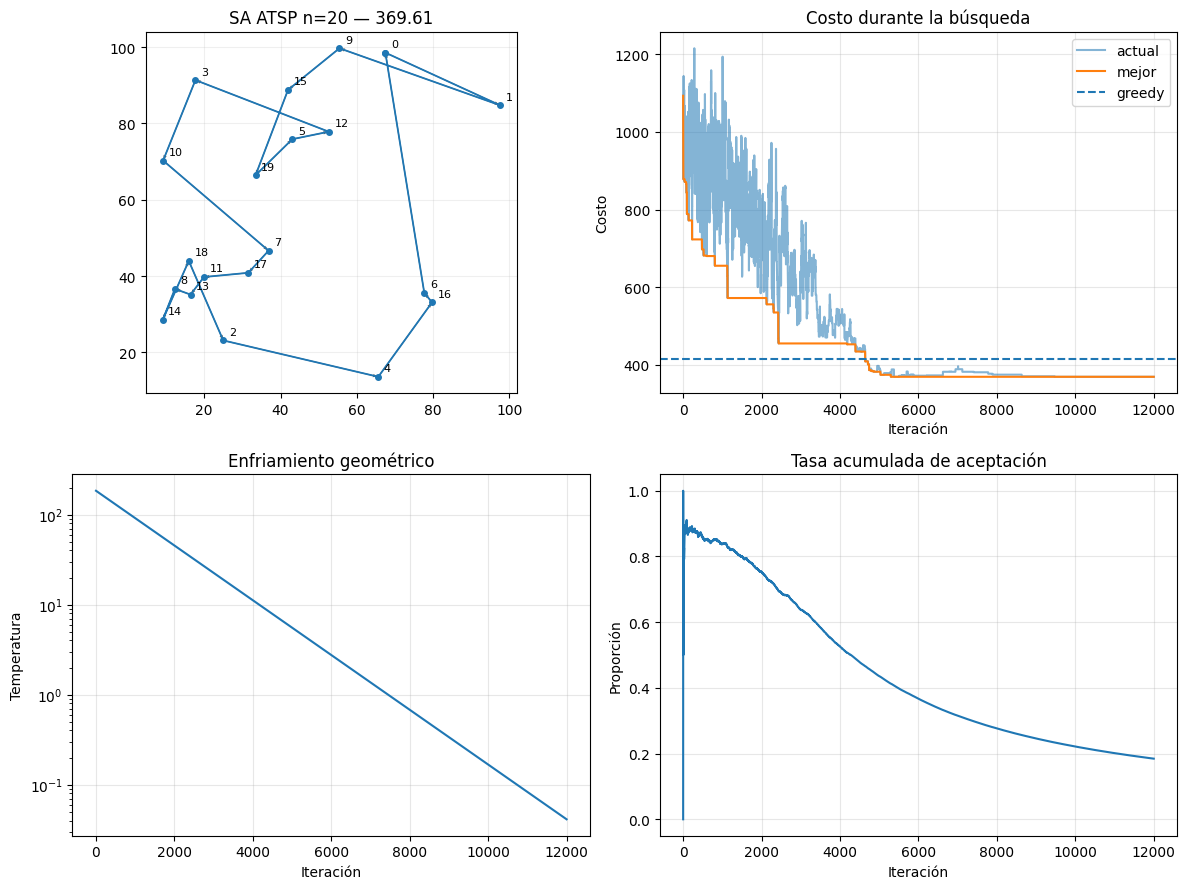

In [3]:
coords20, D20 = INSTANCES[20]
start_seed20 = START_SEEDS[20]
temperature_seed20 = TEMPERATURE_SEEDS[20]
algorithm_seed20 = ALGORITHM_SEEDS[20]

rng_start20 = np.random.default_rng(start_seed20)
start20 = random_tour(20, rng_start20)
greedy20 = nearest_neighbor(D20)
cost20 = lambda tour: tour_cost(tour, D20)

print(f'Semilla maestra       : {RUN_SEED}')
print(f'Semilla instancia     : {INSTANCE_SEEDS[20]}')
print(f'Semilla solución inicial: {start_seed20}')
print(f'Semilla temperatura   : {temperature_seed20}')
print(f'Semilla algoritmo     : {algorithm_seed20}')

T020 = estimate_initial_temperature(
    start20,
    cost20,
    atsp_neighbor,
    target_acceptance=0.80,
    seed=temperature_seed20,
)

best20, value20, trace20 = simulated_annealing(
    start20,
    cost20,
    atsp_neighbor,
    T0=T020,
    alpha=0.9993,
    n_iter=12000,
    seed=algorithm_seed20,
)

print(f'Temperatura inicial : {T020:.3f}')
print(f'Costo inicial azar  : {cost20(start20):.3f}')
print(f'Referencia greedy   : {cost20(greedy20):.3f}')
print(f'Mejor costo SA      : {value20:.3f}')
print(f'Mejora vs. azar     : {100*(cost20(start20)-value20)/cost20(start20):.2f}%')
print(f'Tasa de aceptación  : {100*trace20["acceptance_rate"]:.2f}%')
print(f'Ruta válida         : {validate_tour(best20, 20)}')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
plot_directed_tour(coords20, best20, f'SA ATSP n=20 — {value20:.2f}', ax=axes[0, 0])
axes[0, 1].plot(trace20['current'], alpha=0.55, label='actual')
axes[0, 1].plot(trace20['best'], label='mejor')
axes[0, 1].axhline(cost20(greedy20), linestyle='--', label='greedy')
axes[0, 1].set_title('Costo durante la búsqueda')
axes[0, 1].set_xlabel('Iteración')
axes[0, 1].set_ylabel('Costo')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[1, 0].plot(trace20['temperature'])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Enfriamiento geométrico')
axes[1, 0].set_xlabel('Iteración')
axes[1, 0].set_ylabel('Temperatura')
axes[1, 0].grid(True, alpha=0.3)
accepted = np.asarray(trace20['accepted'])
steps = np.arange(len(accepted))
rate = np.divide(accepted, np.maximum(steps, 1))
axes[1, 1].plot(rate)
axes[1, 1].set_title('Tasa acumulada de aceptación')
axes[1, 1].set_xlabel('Iteración')
axes[1, 1].set_ylabel('Proporción')
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Entradas de 10, 20, 50 y 100 ciudades

In [4]:
SA_CONFIG = {
    10: {'iterations': 7000, 'alpha': 0.9991},
    20: {'iterations': 12000, 'alpha': 0.9993},
    50: {'iterations': 22000, 'alpha': 0.99955},
    100: {'iterations': 35000, 'alpha': 0.99970},
}

sa_results = []
sa_histories = {}
sa_solutions = {}

for execution_id, n in enumerate(SIZES, start=1):
    coords, D = INSTANCES[n]
    cfg = SA_CONFIG[n]
    start_seed = START_SEEDS[n]
    temperature_seed = TEMPERATURE_SEEDS[n]
    algorithm_seed = ALGORITHM_SEEDS[n]

    rng_start = np.random.default_rng(start_seed)
    start = random_tour(n, rng_start)
    greedy = nearest_neighbor(D)
    cost_fn = lambda tour, D=D: tour_cost(tour, D)

    print('\n' + '-' * 72)
    print(f'Ejecución {execution_id}/{len(SIZES)} — Simulated Annealing — n={n}')
    print(f'Semilla de instancia        : {INSTANCE_SEEDS[n]}')
    print(f'Semilla de solución inicial : {start_seed}')
    print(f'Semilla de temperatura      : {temperature_seed}')
    print(f'Semilla de algoritmo        : {algorithm_seed}')

    T0 = estimate_initial_temperature(
        start,
        cost_fn,
        atsp_neighbor,
        target_acceptance=0.80,
        samples=250,
        seed=temperature_seed,
    )

    t0 = time.perf_counter()
    best, value, traces = simulated_annealing(
        start,
        cost_fn,
        atsp_neighbor,
        T0=T0,
        alpha=cfg['alpha'],
        n_iter=cfg['iterations'],
        seed=algorithm_seed,
    )
    elapsed = time.perf_counter() - t0

    random_baseline = cost_fn(start)
    greedy_baseline = cost_fn(greedy)
    sa_solutions[n] = best
    sa_histories[n] = traces['best']
    sa_results.append({
        'ejecucion': execution_id,
        'n': n,
        'semilla_maestra': RUN_SEED,
        'semilla_instancia': INSTANCE_SEEDS[n],
        'semilla_inicio': start_seed,
        'semilla_temperatura': temperature_seed,
        'semilla_algoritmo': algorithm_seed,
        'costo_azar': random_baseline,
        'costo_greedy': greedy_baseline,
        'mejor_costo': value,
        'mejora_vs_azar_%': 100 * (random_baseline - value) / random_baseline,
        'T0': T0,
        'aceptacion_%': 100 * traces['acceptance_rate'],
        'iteraciones': cfg['iterations'],
        'tiempo_s': elapsed,
    })

    print(f'Mejor costo          : {value:.3f}')
    print(f'Tiempo               : {elapsed:.3f} s')

sa_df = pd.DataFrame(sa_results)
display(sa_df.round({
    'costo_azar': 2,
    'costo_greedy': 2,
    'mejor_costo': 2,
    'mejora_vs_azar_%': 2,
    'T0': 2,
    'aceptacion_%': 2,
    'tiempo_s': 3,
}))



------------------------------------------------------------------------
Ejecución 1/4 — Simulated Annealing — n=10
Semilla de instancia        : 1509512877
Semilla de solución inicial : 2130173023
Semilla de temperatura      : 1406711736
Semilla de algoritmo        : 3942391579
Mejor costo          : 204.457
Tiempo               : 4.176 s

------------------------------------------------------------------------
Ejecución 2/4 — Simulated Annealing — n=20
Semilla de instancia        : 3171706597
Semilla de solución inicial : 3938360936
Semilla de temperatura      : 1349906069
Semilla de algoritmo        : 457763124
Mejor costo          : 369.614
Tiempo               : 7.462 s

------------------------------------------------------------------------
Ejecución 3/4 — Simulated Annealing — n=50
Semilla de instancia        : 1282670196
Semilla de solución inicial : 3538522631
Semilla de temperatura      : 2843436968
Semilla de algoritmo        : 1968212227
Mejor costo          : 701.362
Tie

,ejecucion,n,semilla_maestra,semilla_instancia,semilla_inicio,semilla_temperatura,semilla_algoritmo,costo_azar,costo_greedy,mejor_costo,mejora_vs_azar_%,T0,aceptacion_%,iteraciones,tiempo_s
0,1,10,2721965279,1509512877,2130173023,1406711736,3942391579,458.06,244.94,204.46,55.36,189.70,24.66,7000,4.176
1,2,20,2721965279,3171706597,3938360936,1349906069,457763124,1093.04,415.53,369.61,66.18,184.11,18.46,12000,7.462
2,3,50,2721965279,1282670196,3538522631,2843436968,1968212227,2389.87,688.48,701.36,70.65,255.83,16.43,22000,10.721
3,4,100,2721965279,509972492,4012011278,1050748134,3374795676,5048.68,1004.84,1169.50,76.84,323.63,16.99,35000,11.467


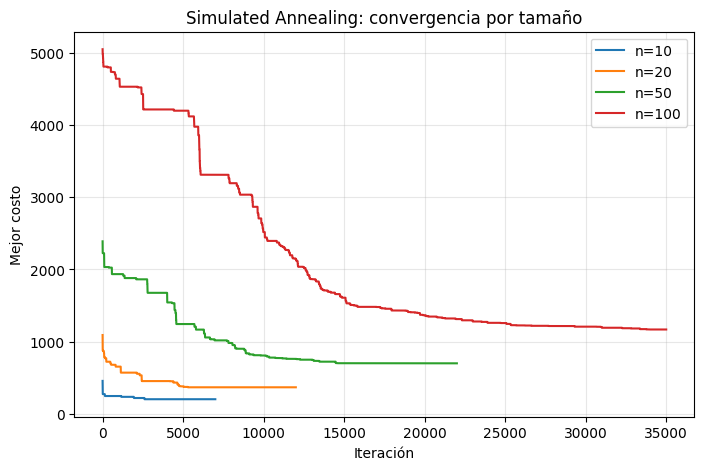

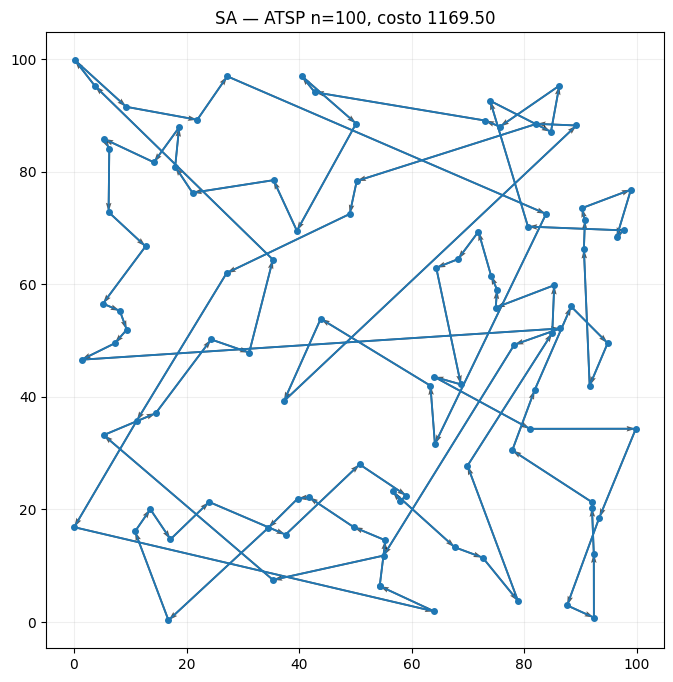

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for n in SIZES:
    ax.plot(sa_histories[n], label=f'n={n}')
ax.set_title('Simulated Annealing: convergencia por tamaño')
ax.set_xlabel('Iteración')
ax.set_ylabel('Mejor costo')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

coords100, D100 = INSTANCES[100]
fig, ax = plt.subplots(figsize=(8, 8))
plot_directed_tour(
    coords100,
    sa_solutions[100],
    f'SA — ATSP n=100, costo {tour_cost(sa_solutions[100], D100):.2f}',
    ax=ax,
)
plt.show()


## 5. Parámetros, trade-offs y complejidad

- `T0` alto aumenta exploración inicial.
- `alpha` cercano a 1 enfría lentamente y consume más iteraciones.
- Un vecindario mixto evita depender de una sola estructura de movimiento.
- El costo aproximado es $O(\text{iteraciones}\times n)$ cuando el costo del
  recorrido se recalcula completamente.
- La tasa de aceptación ayuda a diagnosticar si el proceso está demasiado frío
  o demasiado aleatorio.

## Ejercicios
1. Comparar enfriamiento geométrico, lineal y logarítmico.
2. Usar solo un tipo de movimiento y comparar resultados.
3. Agregar recalentamiento cuando no haya mejoras durante muchas iteraciones.
4. Implementar cálculo incremental de `delta` para intercambio e inserción.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def crear_gantt_ruta(
    ruta,
    D,
    algoritmo,
    n,
    semilla_instancia,
    semilla_algoritmo=None,
    semillas_adicionales=None,
    guardar=False,
    nombre_archivo=None,
    mostrar_tabla=True
):
    
    ruta = np.asarray(ruta, dtype=int)
    D = np.asarray(D, dtype=float)

    if ruta.ndim != 1:
        raise ValueError("La ruta debe ser un arreglo unidimensional.")

    if len(ruta) != n:
        raise ValueError(
            f"La ruta tiene {len(ruta)} ciudades, pero se esperaba n={n}."
        )

    if len(np.unique(ruta)) != n:
        raise ValueError(
            "La ruta contiene ciudades repetidas."
        )

    if not np.array_equal(np.sort(ruta), np.arange(n)):
        raise ValueError(
            "La ruta no contiene exactamente las ciudades entre 0 y n-1."
        )

    if D.shape != (n, n):
        raise ValueError(
            f"La matriz D debe tener dimensiones ({n}, {n})."
        )
    ruta_cerrada = np.append(ruta, ruta[0])

    origenes = ruta_cerrada[:-1]
    destinos = ruta_cerrada[1:]

    costos_tramos = np.array([
        D[origen, destino]
        for origen, destino in zip(origenes, destinos)
    ])

    if not np.all(np.isfinite(costos_tramos)):
        raise ValueError(
            "La ruta contiene desplazamientos con costo infinito."
        )

    inicio_acumulado = np.concatenate([
        [0.0],
        np.cumsum(costos_tramos)[:-1]
    ])

    costo_acumulado = np.cumsum(costos_tramos)
    costo_total = float(costo_acumulado[-1])

    percentil_75 = float(
        np.percentile(costos_tramos, 75)
    )

    df_gantt = pd.DataFrame({
        "paso": np.arange(1, n + 1),
        "origen": origenes,
        "destino": destinos,
        "tramo": [
            f"{paso:03d}. Ciudad {origen} → Ciudad {destino}"
            for paso, origen, destino in zip(
                np.arange(1, n + 1),
                origenes,
                destinos
            )
        ],
        "inicio_acumulado": inicio_acumulado,
        "costo_tramo": costos_tramos,
        "costo_acumulado": costo_acumulado,
        "porcentaje_total": (
            costos_tramos / costo_total
        ) * 100,
        "tramo_costoso": (
            costos_tramos >= percentil_75
        )
    })
    altura = max(
        7,
        min(34, 4 + n * 0.29)
    )

    fig, ax = plt.subplots(
        figsize=(17, altura)
    )

    posiciones_y = np.arange(n)

    barras = ax.barh(
        posiciones_y,
        df_gantt["costo_tramo"],
        left=df_gantt["inicio_acumulado"],
        edgecolor="black",
        linewidth=0.7
    )
    for indice, barra in enumerate(barras):

        es_costoso = bool(
            df_gantt.loc[indice, "tramo_costoso"]
        )

        if es_costoso:
            barra.set_hatch("////")
            barra.set_linewidth(1.3)

        costo = float(
            df_gantt.loc[indice, "costo_tramo"]
        )

        inicio = float(
            df_gantt.loc[
                indice,
                "inicio_acumulado"
            ]
        )
        mostrar_valor = (
            n <= 20
            or es_costoso
        )

        if mostrar_valor:
            ax.text(
                inicio + costo / 2,
                indice,
                f"{costo:.1f}",
                ha="center",
                va="center",
                fontsize=7
            )
    ax.axvline(
        costo_total,
        linestyle="--",
        linewidth=1.6
    )

    ax.set_xlim(
        0,
        costo_total * 1.05
    )

    ax.set_yticks(posiciones_y)

    ax.set_yticklabels(
        df_gantt["tramo"],
        fontsize=7 if n >= 50 else 8
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "Costo acumulado de la ruta"
    )

    ax.set_ylabel(
        "Secuencia de desplazamientos"
    )
    texto_semillas = (
        f"Semilla instancia: {semilla_instancia}"
    )

    if semilla_algoritmo is not None:
        texto_semillas += (
            f" | Semilla algoritmo: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            texto_semillas += (
                f" | {nombre}: {valor}"
            )

    ax.set_title(
        f"{algoritmo} — Carta Gantt de la mejor ruta ATSP\n"
        f"n={n} | costo total={costo_total:.2f}\n"
        f"{texto_semillas}",
        fontsize=13,
        pad=14
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    leyenda = [
        Patch(
            fill=False,
            edgecolor="black",
            hatch="////",
            label=(
                f"Tramo costoso ≥ P75 "
                f"({percentil_75:.2f})"
            )
        ),
        Line2D(
            [0],
            [0],
            linestyle="--",
            label=(
                f"Costo total: "
                f"{costo_total:.2f}"
            )
        )
    ]

    ax.legend(
        handles=leyenda,
        loc="lower right"
    )

    plt.tight_layout()
    if guardar:

        if nombre_archivo is None:
            nombre_normalizado = (
                algoritmo
                .lower()
                .replace(" ", "_")
                .replace("&", "and")
            )

            nombre_archivo = (
                f"gantt_{nombre_normalizado}_n{n}.png"
            )

        fig.savefig(
            nombre_archivo,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"Gráfico guardado: {nombre_archivo}"
        )

    print("\n" + "=" * 72)
    print(f"ALGORITMO: {algoritmo}")
    print(f"NÚMERO DE CIUDADES: {n}")
    print(f"SEMILLA DE INSTANCIA: {semilla_instancia}")

    if semilla_algoritmo is not None:
        print(
            f"SEMILLA DE ALGORITMO: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            print(
                f"{nombre.upper()}: {valor}"
            )

    print(f"COSTO TOTAL: {costo_total:.3f}")
    print(
        f"COSTO PROMEDIO POR TRAMO: "
        f"{costos_tramos.mean():.3f}"
    )
    print(
        f"TRAMO DE MAYOR COSTO: "
        f"{costos_tramos.max():.3f}"
    )
    print(
        f"PERCENTIL 75: "
        f"{percentil_75:.3f}"
    )

    print("\nRuta encontrada:")
    print(
        " → ".join(
            map(str, ruta_cerrada)
        )
    )

    if mostrar_tabla:

        columnas = [
            "paso",
            "origen",
            "destino",
            "costo_tramo",
            "costo_acumulado",
            "porcentaje_total",
            "tramo_costoso"
        ]

        display(
            df_gantt[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

        print("\nCinco tramos de mayor costo:")

        display(
            df_gantt.nlargest(
                5,
                "costo_tramo"
            )[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

    return df_gantt, fig, ax


################################################################################
CARTA GANTT SIMULATED ANNEALING — n=10
Semilla instancia: 1509512877
Semilla solución inicial: 2130173023
Semilla temperatura: 1406711736
Semilla algoritmo: 3942391579
Gráfico guardado: gantt_simulated_annealing_n10_instance_seed_1509512877_start_seed_2130173023_temperature_seed_1406711736_algorithm_seed_3942391579.png

ALGORITMO: Simulated Annealing
NÚMERO DE CIUDADES: 10
SEMILLA DE INSTANCIA: 1509512877
SEMILLA DE ALGORITMO: 3942391579
SEMILLA INICIO: 2130173023
SEMILLA TEMPERATURA: 1406711736
ITERACIONES: 7000
ALPHA: 0.9991
COSTO TOTAL: 204.457
COSTO PROMEDIO POR TRAMO: 20.446
TRAMO DE MAYOR COSTO: 45.507
PERCENTIL 75: 24.386

Ruta encontrada:
0 → 3 → 8 → 2 → 9 → 6 → 7 → 4 → 5 → 1 → 0


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,3,2.820,2.820,1.38,False
1,2,3,8,14.664,17.484,7.17,False
2,3,8,2,35.668,53.152,17.45,True
3,4,2,9,18.544,71.696,9.07,False
4,5,9,6,45.507,117.203,22.26,True
5,6,6,7,20.354,137.556,9.95,False
6,7,7,4,3.757,141.313,1.84,False
7,8,4,5,23.573,164.886,11.53,False
8,9,5,1,14.914,179.800,7.29,False
9,10,1,0,24.657,204.457,12.06,True



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
4,5,9,6,45.507,117.203,22.26,True
2,3,8,2,35.668,53.152,17.45,True
9,10,1,0,24.657,204.457,12.06,True
7,8,4,5,23.573,164.886,11.53,False
5,6,6,7,20.354,137.556,9.95,False


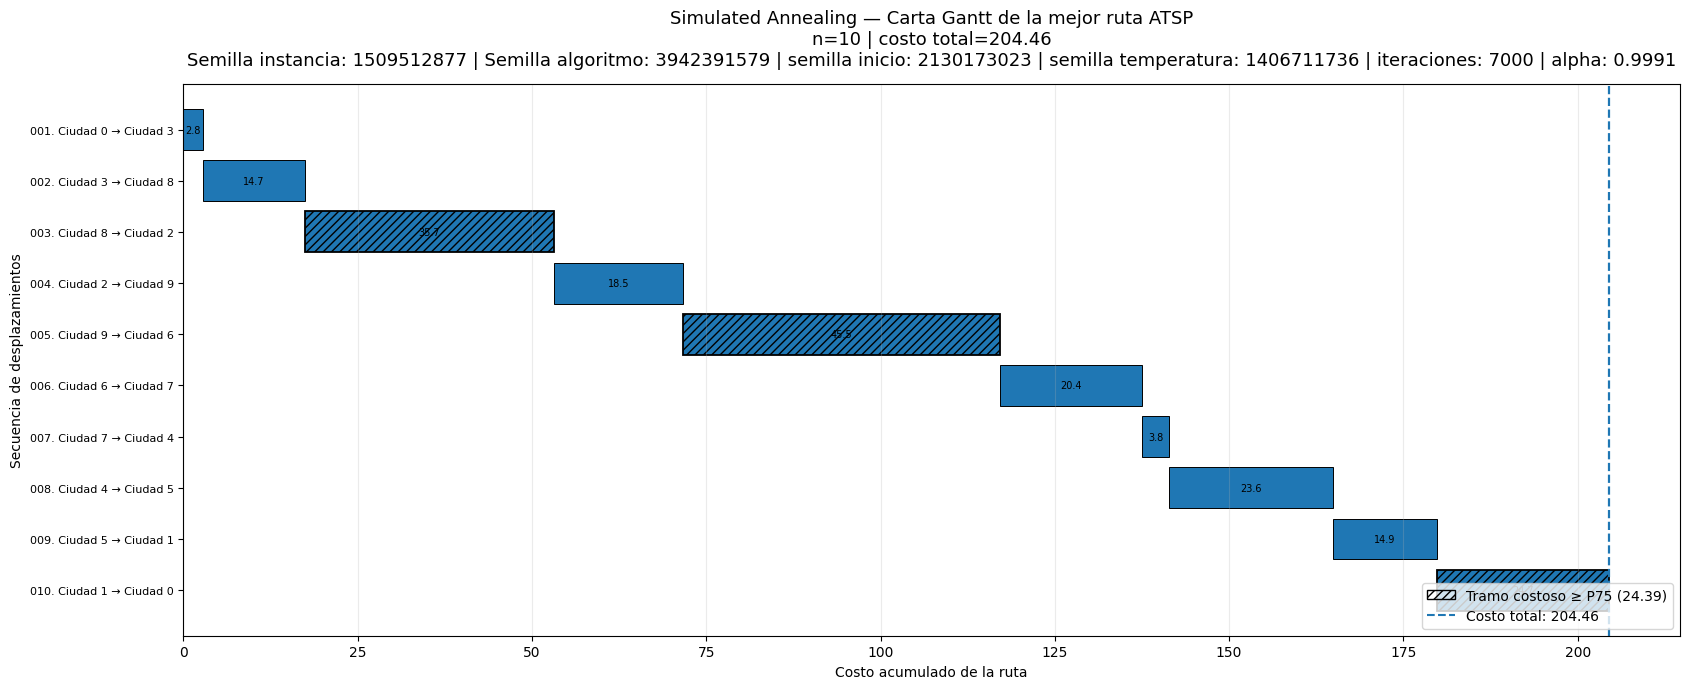


################################################################################
CARTA GANTT SIMULATED ANNEALING — n=20
Semilla instancia: 3171706597
Semilla solución inicial: 3938360936
Semilla temperatura: 1349906069
Semilla algoritmo: 457763124
Gráfico guardado: gantt_simulated_annealing_n20_instance_seed_3171706597_start_seed_3938360936_temperature_seed_1349906069_algorithm_seed_457763124.png

ALGORITMO: Simulated Annealing
NÚMERO DE CIUDADES: 20
SEMILLA DE INSTANCIA: 3171706597
SEMILLA DE ALGORITMO: 457763124
SEMILLA INICIO: 3938360936
SEMILLA TEMPERATURA: 1349906069
ITERACIONES: 12000
ALPHA: 0.9993
COSTO TOTAL: 369.614
COSTO PROMEDIO POR TRAMO: 18.481
TRAMO DE MAYOR COSTO: 50.251
PERCENTIL 75: 27.685

Ruta encontrada:
0 → 1 → 9 → 15 → 19 → 5 → 12 → 3 → 10 → 7 → 17 → 11 → 13 → 8 → 14 → 18 → 2 → 4 → 16 → 6 → 0


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,1,42.902,42.902,11.61,True
1,2,1,9,27.744,70.646,7.51,True
2,3,9,15,14.014,84.661,3.79,False
3,4,15,19,16.616,101.277,4.50,False
4,5,19,5,13.497,114.773,3.65,False
5,6,5,12,7.133,121.907,1.93,False
6,7,12,3,26.931,148.838,7.29,False
7,8,3,10,27.665,176.503,7.48,False
8,9,10,7,29.191,205.694,7.90,True
9,10,7,17,7.500,213.193,2.03,False



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
19,20,6,0,50.251,369.614,13.60,True
0,1,0,1,42.902,42.902,11.61,True
16,17,2,4,30.303,295.989,8.20,True
8,9,10,7,29.191,205.694,7.90,True
1,2,1,9,27.744,70.646,7.51,True


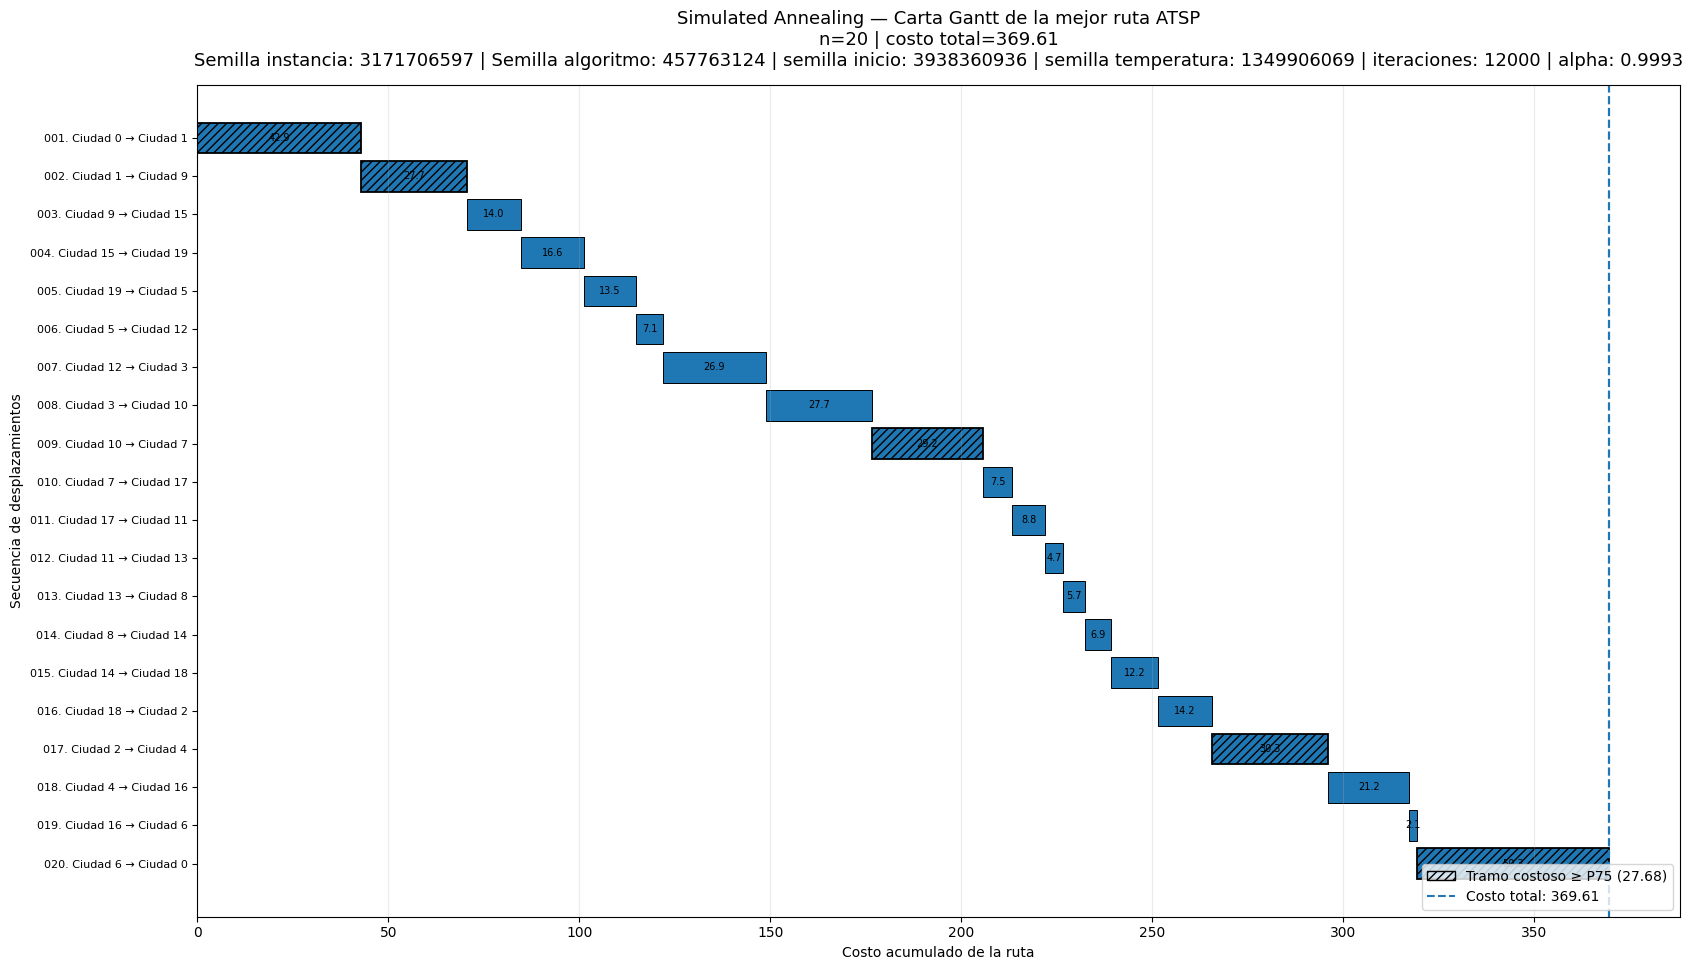


################################################################################
CARTA GANTT SIMULATED ANNEALING — n=50
Semilla instancia: 1282670196
Semilla solución inicial: 3538522631
Semilla temperatura: 2843436968
Semilla algoritmo: 1968212227
Gráfico guardado: gantt_simulated_annealing_n50_instance_seed_1282670196_start_seed_3538522631_temperature_seed_2843436968_algorithm_seed_1968212227.png

ALGORITMO: Simulated Annealing
NÚMERO DE CIUDADES: 50
SEMILLA DE INSTANCIA: 1282670196
SEMILLA DE ALGORITMO: 1968212227
SEMILLA INICIO: 3538522631
SEMILLA TEMPERATURA: 2843436968
ITERACIONES: 22000
ALPHA: 0.99955
COSTO TOTAL: 701.362
COSTO PROMEDIO POR TRAMO: 14.027
TRAMO DE MAYOR COSTO: 48.237
PERCENTIL 75: 19.349

Ruta encontrada:
0 → 39 → 17 → 47 → 38 → 4 → 15 → 1 → 46 → 9 → 6 → 25 → 8 → 30 → 7 → 32 → 44 → 2 → 20 → 26 → 48 → 28 → 40 → 10 → 5 → 43 → 29 → 34 → 14 → 24 → 13 → 36 → 23 → 41 → 12 → 11 → 45 → 16 → 49 → 19 → 21 → 42 → 27 → 37 → 33 → 18 → 31 → 35 → 3 → 22 → 0



################################################################################
CARTA GANTT SIMULATED ANNEALING — n=100
Semilla instancia: 509972492
Semilla solución inicial: 4012011278
Semilla temperatura: 1050748134
Semilla algoritmo: 3374795676
Gráfico guardado: gantt_simulated_annealing_n100_instance_seed_509972492_start_seed_4012011278_temperature_seed_1050748134_algorithm_seed_3374795676.png

ALGORITMO: Simulated Annealing
NÚMERO DE CIUDADES: 100
SEMILLA DE INSTANCIA: 509972492
SEMILLA DE ALGORITMO: 3374795676
SEMILLA INICIO: 4012011278
SEMILLA TEMPERATURA: 1050748134
ITERACIONES: 35000
ALPHA: 0.9997
COSTO TOTAL: 1169.500
COSTO PROMEDIO POR TRAMO: 11.695
TRAMO DE MAYOR COSTO: 53.645
PERCENTIL 75: 15.096

Ruta encontrada:
0 → 17 → 15 → 66 → 13 → 8 → 25 → 40 → 16 → 74 → 37 → 19 → 97 → 61 → 6 → 69 → 92 → 10 → 36 → 79 → 52 → 68 → 41 → 5 → 31 → 91 → 28 → 49 → 48 → 29 → 34 → 76 → 2 → 54 → 39 → 35 → 59 → 45 → 50 → 46 → 30 → 21 → 67 → 93 → 94 → 26 → 55 → 64 → 51 → 27 → 22 → 3 → 11 → 43

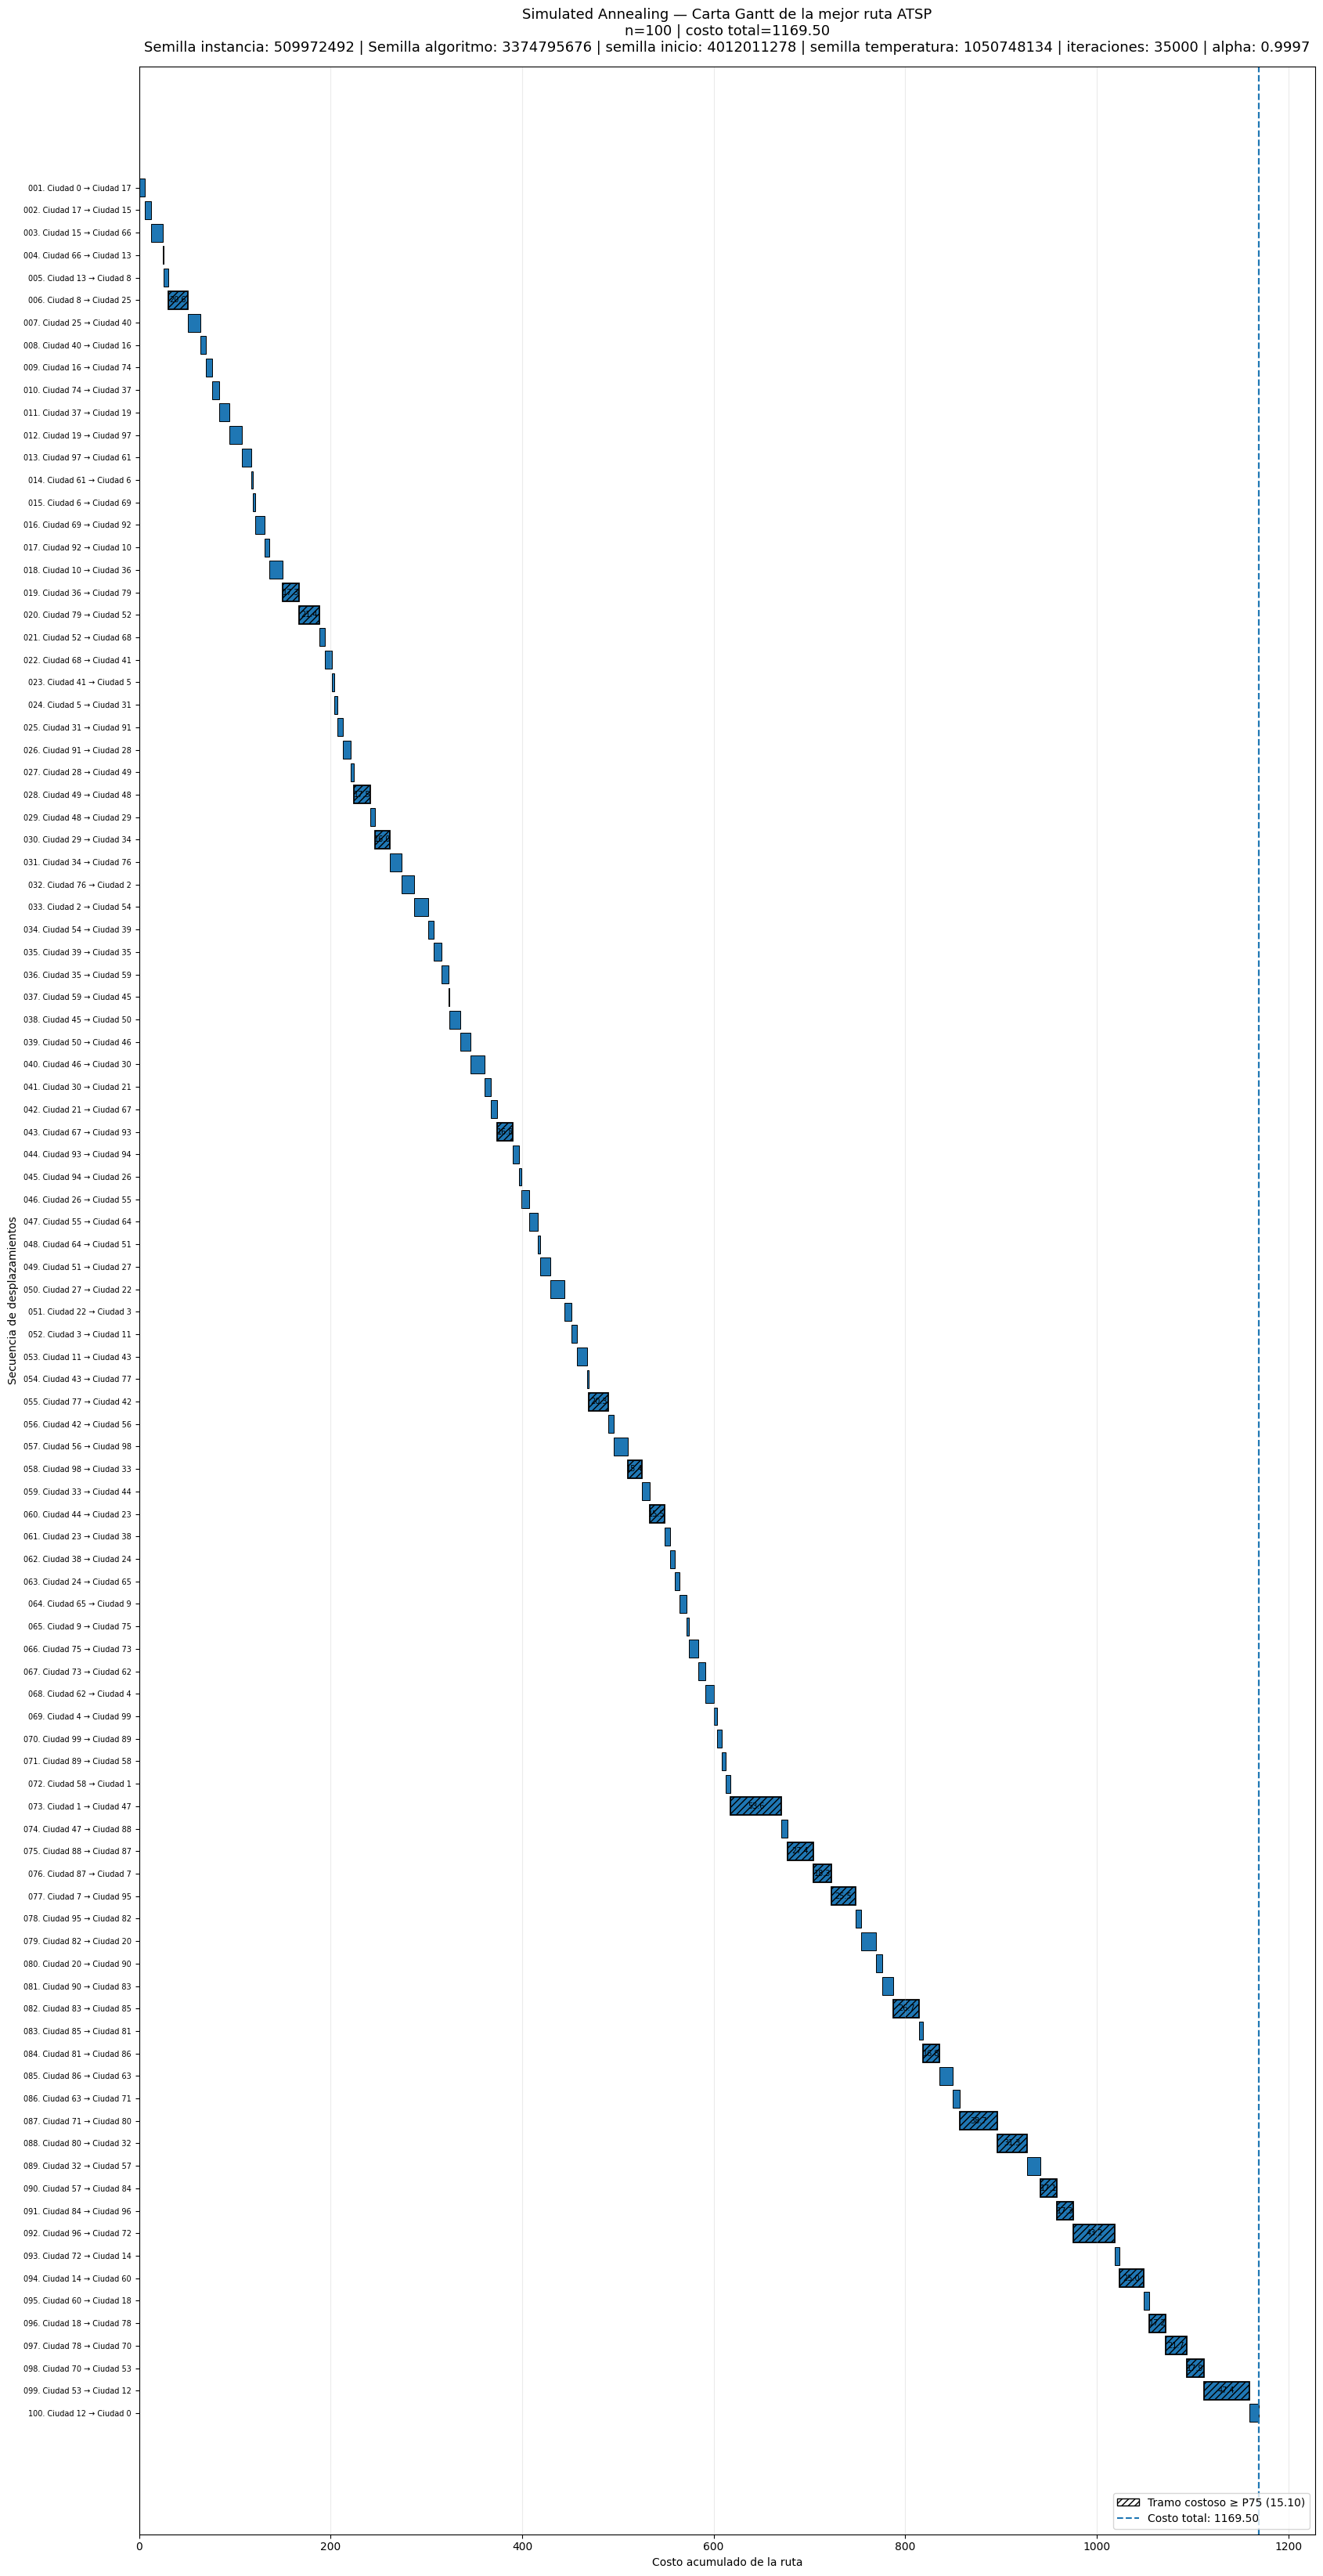

In [7]:
sa_gantt = {}

for n in SIZES:

    coords, D = INSTANCES[n]
    mejor_ruta = sa_solutions[n]

    print("\n" + "#" * 80)
    print(f"CARTA GANTT SIMULATED ANNEALING — n={n}")
    print(
        f"Semilla instancia: "
        f"{INSTANCE_SEEDS[n]}"
    )
    print(
        f"Semilla solución inicial: "
        f"{START_SEEDS[n]}"
    )
    print(
        f"Semilla temperatura: "
        f"{TEMPERATURE_SEEDS[n]}"
    )
    print(
        f"Semilla algoritmo: "
        f"{ALGORITHM_SEEDS[n]}"
    )

    df_gantt, fig, ax = crear_gantt_ruta(
        ruta=mejor_ruta,
        D=D,
        algoritmo="Simulated Annealing",
        n=n,
        semilla_instancia=INSTANCE_SEEDS[n],
        semilla_algoritmo=ALGORITHM_SEEDS[n],
        semillas_adicionales={
            "semilla inicio": START_SEEDS[n],
            "semilla temperatura": TEMPERATURE_SEEDS[n],
            "iteraciones": SA_CONFIG[n]["iterations"],
            "alpha": SA_CONFIG[n]["alpha"]
        },
        guardar=True,
        nombre_archivo=(
            f"gantt_simulated_annealing_n{n}_"
            f"instance_seed_{INSTANCE_SEEDS[n]}_"
            f"start_seed_{START_SEEDS[n]}_"
            f"temperature_seed_{TEMPERATURE_SEEDS[n]}_"
            f"algorithm_seed_{ALGORITHM_SEEDS[n]}.png"
        ),
        mostrar_tabla=(n <= 20)
    )

    sa_gantt[n] = df_gantt

    plt.show()